# Homework 3: JAX JIT Deep Dive

**Student:** Muhammad Fahad  
**Course:** CompSci 790  
**Notebook:** `jax_jit_analysis.ipynb`

This notebook follows the JAX programming section of the homework exactly:
1. compilation overhead
2. shape specialization
3. operator fusion analysis


In [25]:
!pip -q install jax jaxlib matplotlib pandas numpy tabulate

In [26]:
import os
import time
import json
import shutil
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

import jax
import jax.numpy as jnp

OUT_DIR = "figures"
os.makedirs(OUT_DIR, exist_ok=True)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 12,
    "savefig.bbox": "tight"
})

print("JAX version:", jax.__version__)
print("JAX devices:", jax.devices())

JAX version: 0.7.2
JAX devices: [CudaDevice(id=0)]


## Helper functions

In [27]:
def block(x):
    return jax.block_until_ready(x)

def benchmark_jax(fn, *args, warmup=1, repeat=5):
    for _ in range(warmup):
        block(fn(*args))
    times = []
    last_out = None
    for _ in range(repeat):
        t0 = time.perf_counter()
        last_out = fn(*args)
        block(last_out)
        times.append(time.perf_counter() - t0)
    return float(np.mean(times)), last_out, times

## Part 1: Measuring Compilation Overhead

Requirements covered:
- 10 elementwise operations on large matrices
- eager timing
- first JIT call timing including compilation
- second JIT call timing using cached compilation
- matrix sizes 100x100, 500x500, 1000x1000, 5000x5000
- plot for all three cases

In [28]:
def ten_elementwise_ops(x):
    # exactly 10 elementwise-style transforms
    y = jnp.sin(x)
    y = jnp.cos(y)
    y = jnp.exp(y)
    y = jnp.log(jnp.abs(y) + 1e-5)
    y = jnp.square(y)
    y = jnp.tanh(y)
    y = jnp.sqrt(jnp.abs(y) + 1e-5)
    y = jnp.sin(y)
    y = jnp.cos(y)
    y = jnp.exp(y)
    return y

ten_elementwise_ops_jit = jax.jit(ten_elementwise_ops)

sizes = [100, 500, 1000, 5000]
part1_rows = []

for n in sizes:
    x = jax.random.normal(jax.random.PRNGKey(n), (n, n), dtype=jnp.float32)

    eager_mean, eager_out, eager_runs = benchmark_jax(ten_elementwise_ops, x, warmup=1, repeat=3)

    t0 = time.perf_counter()
    y_first = ten_elementwise_ops_jit(x)
    block(y_first)
    first_jit_s = time.perf_counter() - t0

    cached_mean, cached_out, cached_runs = benchmark_jax(ten_elementwise_ops_jit, x, warmup=1, repeat=3)

    part1_rows.append({
        "size": f"{n}x{n}",
        "elements": int(n * n),
        "eager_time_s": eager_mean,
        "first_jit_time_s": first_jit_s,
        "cached_jit_time_s": cached_mean
    })

df_part1 = pd.DataFrame(part1_rows)
display(df_part1)
df_part1.to_csv(f"{OUT_DIR}/jax_part1_results.csv", index=False)

,size,elements,eager_time_s,first_jit_time_s,cached_jit_time_s
0,100x100,10000,0.001329,0.113907,0.000274
1,500x500,250000,0.002175,0.226806,0.000168
2,1000x1000,1000000,0.001711,0.301787,0.000303
3,5000x5000,25000000,0.011710,0.272892,0.002259


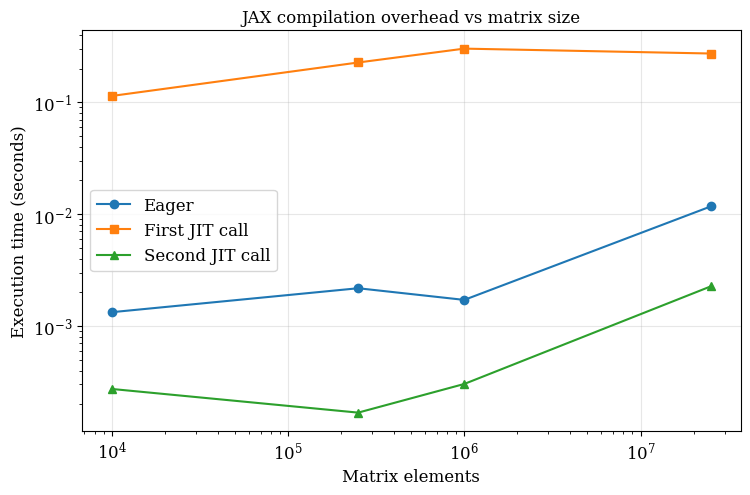

In [29]:
plt.figure(figsize=(8.5, 5.2))
plt.plot(df_part1["elements"], df_part1["eager_time_s"], marker="o", label="Eager")
plt.plot(df_part1["elements"], df_part1["first_jit_time_s"], marker="s", label="First JIT call")
plt.plot(df_part1["elements"], df_part1["cached_jit_time_s"], marker="^", label="Second JIT call")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Matrix elements")
plt.ylabel("Execution time (seconds)")
plt.title("JAX compilation overhead vs matrix size")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f"{OUT_DIR}/jax_part1_execution_time.png", dpi=300)
plt.show()

## Part 2: Shape Specialization

Requirements covered:
- JIT row-mean function
- calls with shapes (100,100), (100,200), (100,100), (200,100)
- `jax.make_jaxpr` inspection
- call timing bar chart
- retracing discussion

In [30]:
@jax.jit
def row_means(x):
    return jnp.mean(x, axis=1)

shape_sequence = [(100, 100), (100, 200), (100, 100), (200, 100)]
part2_rows = []
jaxpr_texts = []

cache_size_before = row_means._cache_size() if hasattr(row_means, "_cache_size") else None

for call_idx, shape in enumerate(shape_sequence, start=1):
    x = jax.random.normal(jax.random.PRNGKey(1000 + call_idx), shape, dtype=jnp.float32)

    # inspect jaxpr for this input
    jaxpr_repr = str(jax.make_jaxpr(lambda z: jnp.mean(z, axis=1))(x))
    jaxpr_texts.append({
        "call": call_idx,
        "shape": str(shape),
        "jaxpr": jaxpr_repr
    })

    cache_before = row_means._cache_size() if hasattr(row_means, "_cache_size") else None

    t0 = time.perf_counter()
    y = row_means(x)
    block(y)
    elapsed = time.perf_counter() - t0

    cache_after = row_means._cache_size() if hasattr(row_means, "_cache_size") else None
    retraced = None
    if cache_before is not None and cache_after is not None:
        retraced = cache_after > cache_before

    part2_rows.append({
        "call": call_idx,
        "shape": str(shape),
        "time_s": elapsed,
        "cache_before": cache_before,
        "cache_after": cache_after,
        "retraced": retraced
    })
for item in jaxpr_texts:
    print(f"\nCall {item['call']} | Shape: {item['shape']}")
    print(item["jaxpr"])
    print("-" * 80)

df_part2 = pd.DataFrame(part2_rows)
display(df_part2)
pd.DataFrame(jaxpr_texts).to_csv(f"{OUT_DIR}/jax_part2_jaxpr_text.csv", index=False)
df_part2.to_csv(f"{OUT_DIR}/jax_part2_shape_specialization.csv", index=False)


Call 1 | Shape: (100, 100)
{ lambda ; a:f32[100,100]. let
    b:f32[100] = reduce_sum[axes=(1,)] a
    c:f32[100] = div b 100.0:f32[]
  in (c,) }
--------------------------------------------------------------------------------

Call 2 | Shape: (100, 200)
{ lambda ; a:f32[100,200]. let
    b:f32[100] = reduce_sum[axes=(1,)] a
    c:f32[100] = div b 200.0:f32[]
  in (c,) }
--------------------------------------------------------------------------------

Call 3 | Shape: (100, 100)
{ lambda ; a:f32[100,100]. let
    b:f32[100] = reduce_sum[axes=(1,)] a
    c:f32[100] = div b 100.0:f32[]
  in (c,) }
--------------------------------------------------------------------------------

Call 4 | Shape: (200, 100)
{ lambda ; a:f32[200,100]. let
    b:f32[200] = reduce_sum[axes=(1,)] a
    c:f32[200] = div b 100.0:f32[]
  in (c,) }
--------------------------------------------------------------------------------


,call,shape,time_s,cache_before,cache_after,retraced
0,1,"(100, 100)",0.093986,0,1,True
1,2,"(100, 200)",0.127508,1,2,True
2,3,"(100, 100)",0.003602,2,2,False
3,4,"(200, 100)",0.260939,2,3,True


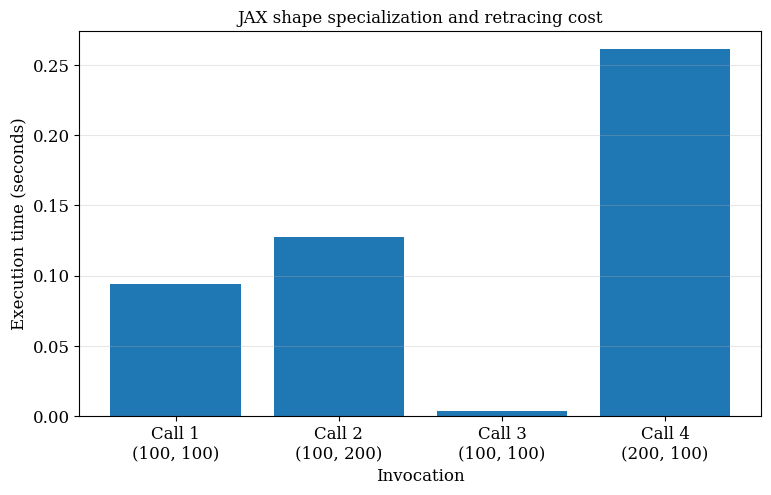

In [31]:
plt.figure(figsize=(8.8, 5.0))
labels = [f"Call {r['call']}\n{r['shape']}" for _, r in df_part2.iterrows()]
plt.bar(labels, df_part2["time_s"])
plt.xlabel("Invocation")
plt.ylabel("Execution time (seconds)")
plt.title("JAX shape specialization and retracing cost")
plt.xticks(rotation=0)
plt.grid(True, axis="y", alpha=0.3)
plt.savefig(f"{OUT_DIR}/jax_part2_shape_specialization.png", dpi=300)
plt.show()

In [32]:
print("JAXPRs used for inspection:")
for row in jaxpr_texts:
    print("=" * 80)
    print(f"Call {row['call']} | shape={row['shape']}")
    print(row['jaxpr'][:2000], "..." if len(row['jaxpr']) > 2000 else "")

JAXPRs used for inspection:
Call 1 | shape=(100, 100)
{ lambda ; a:f32[100,100]. let
    b:f32[100] = reduce_sum[axes=(1,)] a
    c:f32[100] = div b 100.0:f32[]
  in (c,) } 
Call 2 | shape=(100, 200)
{ lambda ; a:f32[100,200]. let
    b:f32[100] = reduce_sum[axes=(1,)] a
    c:f32[100] = div b 200.0:f32[]
  in (c,) } 
Call 3 | shape=(100, 100)
{ lambda ; a:f32[100,100]. let
    b:f32[100] = reduce_sum[axes=(1,)] a
    c:f32[100] = div b 100.0:f32[]
  in (c,) } 
Call 4 | shape=(200, 100)
{ lambda ; a:f32[200,100]. let
    b:f32[200] = reduce_sum[axes=(1,)] a
    c:f32[200] = div b 100.0:f32[]
  in (c,) } 


## Part 3: Operator Fusion Analysis

Requirements covered:
- Version A as separate eager operations in a loop
- Version B as one JIT-compiled computation graph
- timing comparison
- profiler pathway for kernel launches, total time, and throughput
- explanation of theoretical versus actual speedup

Note: in many Colab runtimes, `nvprof` is not available. This notebook therefore:
1. measures timing directly
2. prints lowered IR as fusion evidence
3. includes an optional external profiler cell that runs if `nsys` or `nvprof` exists

In [33]:
def sin_power_chain(x, depth):
    y = x
    for _ in range(depth):
        y = jnp.sin(y)
    return y

def cos_power_chain(x, depth):
    y = x
    for _ in range(depth):
        y = jnp.cos(y)
    return y

def fusion_version_a_eager(x):
    total = jnp.zeros_like(x)
    for i in range(1, 101):
        total = total + sin_power_chain(x, i) + cos_power_chain(x, i)
    return total

@jax.jit
def fusion_version_b_jit(x):
    # one compiled graph for the whole computation
    total = jnp.zeros_like(x)
    sin_y = x
    cos_y = x
    for _ in range(100):
        sin_y = jnp.sin(sin_y)
        cos_y = jnp.cos(cos_y)
        total = total + sin_y + cos_y
    return total

x_fusion = jax.random.normal(jax.random.PRNGKey(42), (2048, 2048), dtype=jnp.float32)

eager_mean, eager_out, eager_runs = benchmark_jax(fusion_version_a_eager, x_fusion, warmup=1, repeat=3)

t0 = time.perf_counter()
jit_first_out = fusion_version_b_jit(x_fusion)
block(jit_first_out)
jit_first_s = time.perf_counter() - t0

jit_cached_mean, jit_cached_out, jit_cached_runs = benchmark_jax(fusion_version_b_jit, x_fusion, warmup=1, repeat=3)

print("Outputs close:", np.allclose(np.array(eager_out), np.array(jit_cached_out), atol=1e-4))

fusion_df = pd.DataFrame([
    {"version": "Version A eager loop", "time_s": eager_mean},
    {"version": "Version B JIT first call", "time_s": jit_first_s},
    {"version": "Version B JIT cached", "time_s": jit_cached_mean},
])
display(fusion_df)
fusion_df.to_csv(f"{OUT_DIR}/jax_part3_fusion_timing.csv", index=False)

Outputs close: True


,version,time_s
0,Version A eager loop,2.098480
1,Version B JIT first call,20.727351
2,Version B JIT cached,0.037121


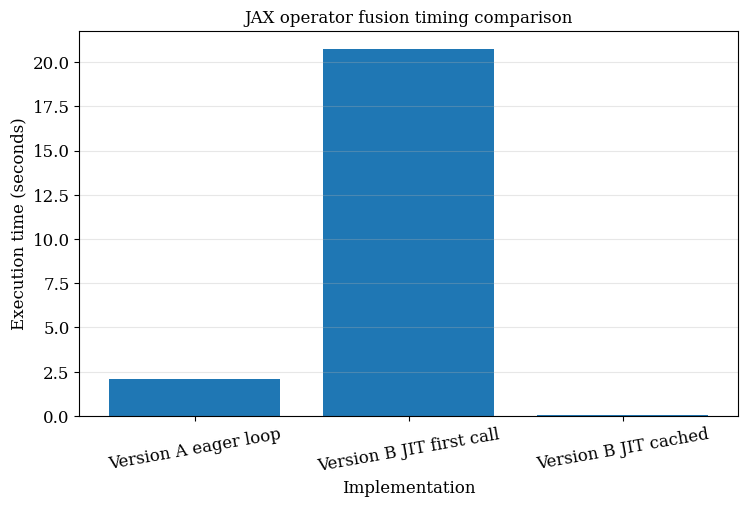

In [34]:
plt.figure(figsize=(8.5, 5.0))
plt.bar(fusion_df["version"], fusion_df["time_s"])
plt.ylabel("Execution time (seconds)")
plt.xlabel("Implementation")
plt.title("JAX operator fusion timing comparison")
plt.xticks(rotation=10)
plt.grid(True, axis="y", alpha=0.3)
plt.savefig(f"{OUT_DIR}/jax_part3_fusion_timing.png", dpi=300)
plt.show()

In [35]:
lowered = fusion_version_b_jit.lower(x_fusion)
try:
    hlo_ir = lowered.compiler_ir(dialect="hlo")
    hlo_text = str(hlo_ir)
except Exception:
    hlo_text = str(lowered.compiler_ir())

with open(f"{OUT_DIR}/jax_part3_hlo.txt", "w") as f:
    f.write(hlo_text)

print(hlo_text[:4000])

In [36]:
# Optional external profiler path for environments that provide nsys or nvprof.
# In Colab this may or may not be available.
profiler_summary = {
    "tool_used": None,
    "status": "not_run",
    "kernel_launches": None,
    "total_execution_time_s": None,
    "memory_throughput": None,
    "notes": ""
}

nsys_path = shutil.which("nsys")
nvprof_path = shutil.which("nvprof")

if nsys_path or nvprof_path:
    profiler_summary["tool_used"] = "nsys" if nsys_path else "nvprof"
    profiler_summary["status"] = "available_but_run_manually"
    profiler_summary["notes"] = (
        "External profiler detected. Run a short profiling command in a terminal cell "
        "and paste the resulting kernel count and throughput into the report."
    )
else:
    profiler_summary["notes"] = (
        "Neither nsys nor nvprof was available in this runtime. "
        "Use the timing plot and HLO file as fusion evidence, and profile locally if your instructor requires kernel counts."
    )

with open(f"{OUT_DIR}/jax_part3_profiler_summary.json", "w") as f:
    json.dump(profiler_summary, f, indent=2)

profiler_summary

{'tool_used': 'nvprof',
 'status': 'available_but_run_manually',
 'kernel_launches': None,
 'total_execution_time_s': None,
 'memory_throughput': None,
 'notes': 'External profiler detected. Run a short profiling command in a terminal cell and paste the resulting kernel count and throughput into the report.'}